# Card Cost Center Analysis
**Neobankless Brasil LTDA — Rain Card Program**

Reference invoice: NKEMEJLO-0008 (February 2026, $6,693.58 USD)

This notebook covers:
1. Load invoice and inspect cost breakdown
2. Weighted average cost per transaction
3. Cost contribution by category
4. Sensitivity analysis — which driver moves the needle most
5. What-if scenario comparison
6. Linear projection model
7. Cost curve — volume sensitivity

In [1]:
import sys
sys.path.insert(0, '..')  # makes nbs_bi importable from notebooks/

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from nbs_bi.cards.models import CardCostModel
from nbs_bi.cards.simulator import CardCostSimulator

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Load Invoice

In [2]:
# Option A — from the JSON actuals file (SPEC interface)
model = CardCostModel.from_invoice('../data/invoices/Invoice-NKEMEJLO-0008-actuals.json')

# Option B — hardcoded February 2026 reference (no file needed)
# model = CardCostModel.from_february_2026()

breakdown = model.cost_breakdown()
print(f"Invoice: {model.inputs.invoice_id}  |  Period: {model.inputs.period}")
print(f"Total: ${breakdown.total:,.2f}  |  Transactions: {model.inputs.n_transactions:,}")

Invoice: NKEMEJLO-0008  |  Period: 2026-02
Total: $6,693.57  |  Transactions: 6,885


## 2. Cost Breakdown Table

In [3]:
bd_dict = breakdown.as_dict()
contributions = model.cost_contribution_pct()

df_breakdown = pd.DataFrame([
    {'line_item': k, 'amount_usd': v, 'pct_of_total': contributions.get(k, 0)}
    for k, v in bd_dict.items() if k != 'total'
]).sort_values('amount_usd', ascending=False).reset_index(drop=True)

df_breakdown.style \
    .format({'amount_usd': '${:,.2f}', 'pct_of_total': '{:.2f}%'}) \
    .bar(subset=['amount_usd'], color='#4CAF50') \
    .set_caption(f"Cost Breakdown — Total: ${breakdown.total:,.2f}")

,line_item,amount_usd,pct_of_total
0,visa_infinite,"$1,502.80",22.45%
1,network_tx_cost,"$1,377.00",20.57%
2,base_program,"$1,000.00",14.94%
3,share_token,$968.75,14.47%
4,transaction_fee,$516.38,7.71%
5,network_volume,$390.44,5.83%
6,cross_border,$239.94,3.58%
7,visa_platinum,$207.25,3.10%
8,applepay_amount,$175.78,2.63%
9,applepay_count,$124.14,1.85%


## 3. Weighted Average Cost per Transaction

In [4]:
cost_per_tx = model.cost_per_transaction()

print(f"Total cost:           ${breakdown.total:>10,.2f}")
print(f"Transactions:         {model.inputs.n_transactions:>10,}")
print(f"Cost per transaction: ${cost_per_tx:>10.4f}")
print()
print("Cost decomposed per transaction (each line item / total txs):")
for item, amount in breakdown.sorted_by_amount():
    cpt_item = amount / model.inputs.n_transactions
    print(f"  {item:<35} ${cpt_item:.4f}")

Total cost:           $  6,693.57
Transactions:              6,885
Cost per transaction: $    0.9722

Cost decomposed per transaction (each line item / total txs):
  visa_infinite                       $0.2183
  network_tx_cost                     $0.2000
  base_program                        $0.1452
  share_token                         $0.1407
  transaction_fee                     $0.0750
  network_volume                      $0.0567
  cross_border                        $0.0348
  visa_platinum                       $0.0301
  applepay_amount                     $0.0255
  applepay_count                      $0.0180
  virtual_cards                       $0.0168
  googlepay_count                     $0.0057
  verify_intl                         $0.0046
  fee_3ds                             $0.0003
  verify_domestic                     $0.0002
  network_3ds_cost                    $0.0002
  chip_auth_intl                      $0.0000


## 4. Cost Contribution — Horizontal Bar Chart

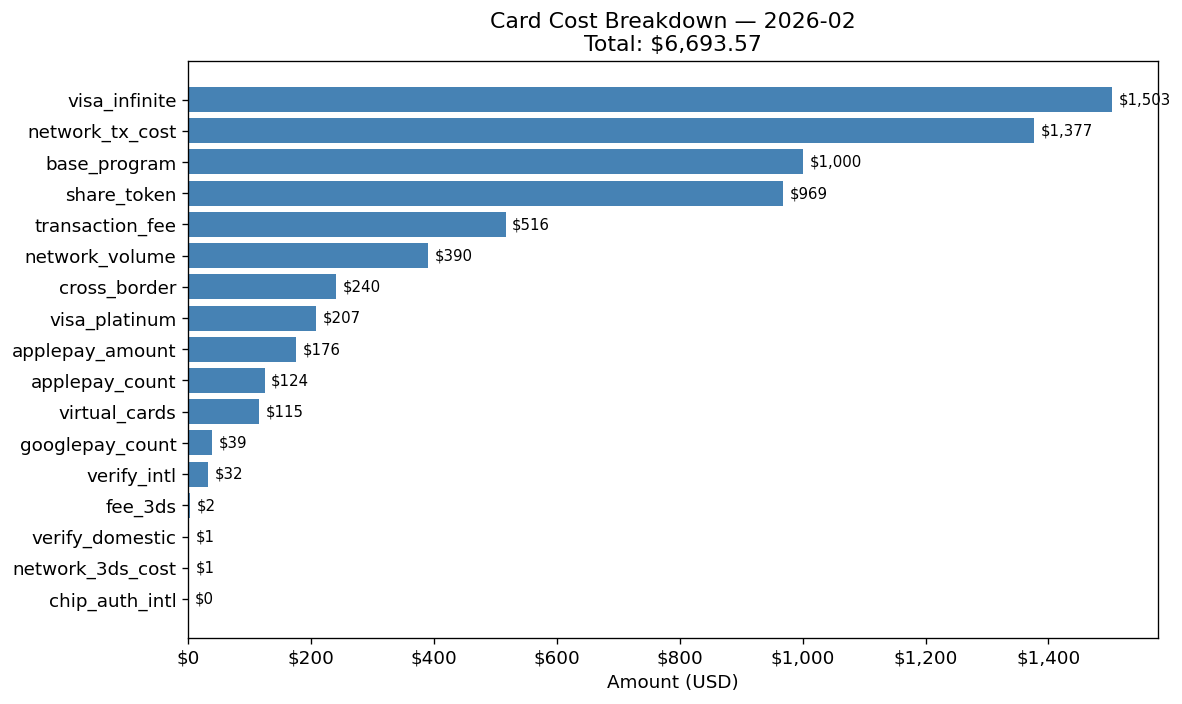

In [5]:
df_plot = df_breakdown.sort_values('amount_usd')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_plot['line_item'], df_plot['amount_usd'], color='steelblue')
ax.bar_label(bars, fmt='${:,.0f}', padding=4, fontsize=9)
ax.set_xlabel('Amount (USD)')
ax.set_title(f'Card Cost Breakdown — {model.inputs.period}\nTotal: ${breakdown.total:,.2f}')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## 5. Sensitivity Analysis

Which input, when increased by 10%, causes the biggest dollar increase in total cost?

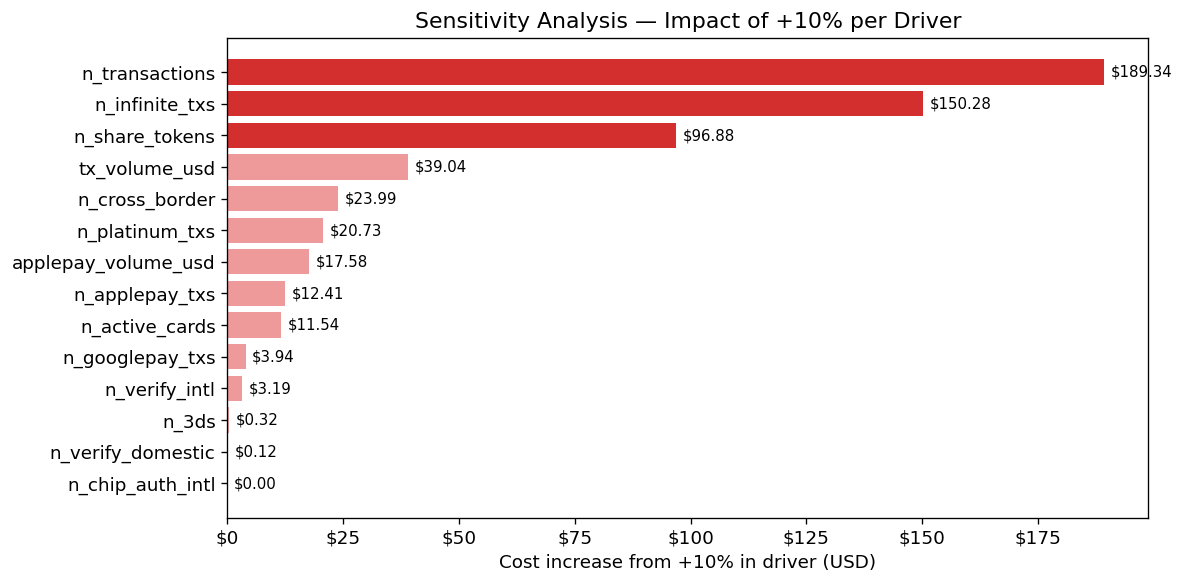

,driver,delta_cost_usd
0,n_transactions,$189.34
1,n_infinite_txs,$150.28
2,n_share_tokens,$96.88
3,tx_volume_usd,$39.04
4,n_cross_border,$23.99
5,n_platinum_txs,$20.73
6,applepay_volume_usd,$17.58
7,n_applepay_txs,$12.41
8,n_active_cards,$11.54
9,n_googlepay_txs,$3.94


In [15]:
sensitivity = model.sensitivity_analysis(delta=0.10)

df_sens = pd.DataFrame([
    {'driver': k, 'delta_cost_usd': v}
    for k, v in sensitivity.items() if v > 0
]).sort_values('delta_cost_usd', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d32f2f' if i < 3 else '#ef9a9a' for i in range(len(df_sens))]
bars = ax.barh(df_sens['driver'][::-1], df_sens['delta_cost_usd'][::-1], color=colors[::-1])
ax.bar_label(bars, fmt='${:,.2f}', padding=4, fontsize=9)
ax.set_xlabel('Cost increase from +10% in driver (USD)')
ax.set_title('Sensitivity Analysis — Impact of +10% per Driver')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

df_sens.style.format({'delta_cost_usd': '${:,.2f}'})

## 6. What-If Scenario Comparison

In [7]:
sim = CardCostSimulator(model)  # accepts CardCostModel directly

scenarios = [
    {'label': 'Feb 2026 (actual)',   'n_transactions': 6_885,  'n_active_cards': 577,   'n_infinite_txs': 884},
    {'label': 'Conservative (-20%)', 'n_transactions': 5_500,  'n_active_cards': 500,   'n_infinite_txs': 700},
    {'label': 'Base (+20%)',         'n_transactions': 8_200,  'n_active_cards': 650,   'n_infinite_txs': 1_000},
    {'label': 'Growth (2x txs)',     'n_transactions': 13_770, 'n_active_cards': 1_000, 'n_infinite_txs': 1_700},
    {'label': 'Shift to Platinum',   'n_transactions': 6_885,  'n_active_cards': 577,   'n_infinite_txs': 200,  'n_platinum_txs': 1_500},
]

results = sim.compare_scenarios(scenarios)

df_scenarios = pd.DataFrame([r.summary() for r in results])
df_scenarios.style \
    .format({'total_cost_usd': '${:,.2f}', 'cost_per_transaction_usd': '${:.4f}'}) \
    .bar(subset=['total_cost_usd'], color='#2196F3') \
    .set_caption('What-If Scenario Comparison')

,scenario,total_cost_usd,cost_per_transaction_usd,n_transactions,n_active_cards
0,Feb 2026 (actual),"$6,693.57",$0.9722,6885,577
1,Conservative (-20%),"$5,984.50",$1.0881,5500,500
2,Base (+20%),"$7,267.00",$0.8862,8200,650
3,Growth (2x txs),"$10,058.75",$0.7305,13770,1000
4,Shift to Platinum,"$5,698.52",$0.8277,6885,577


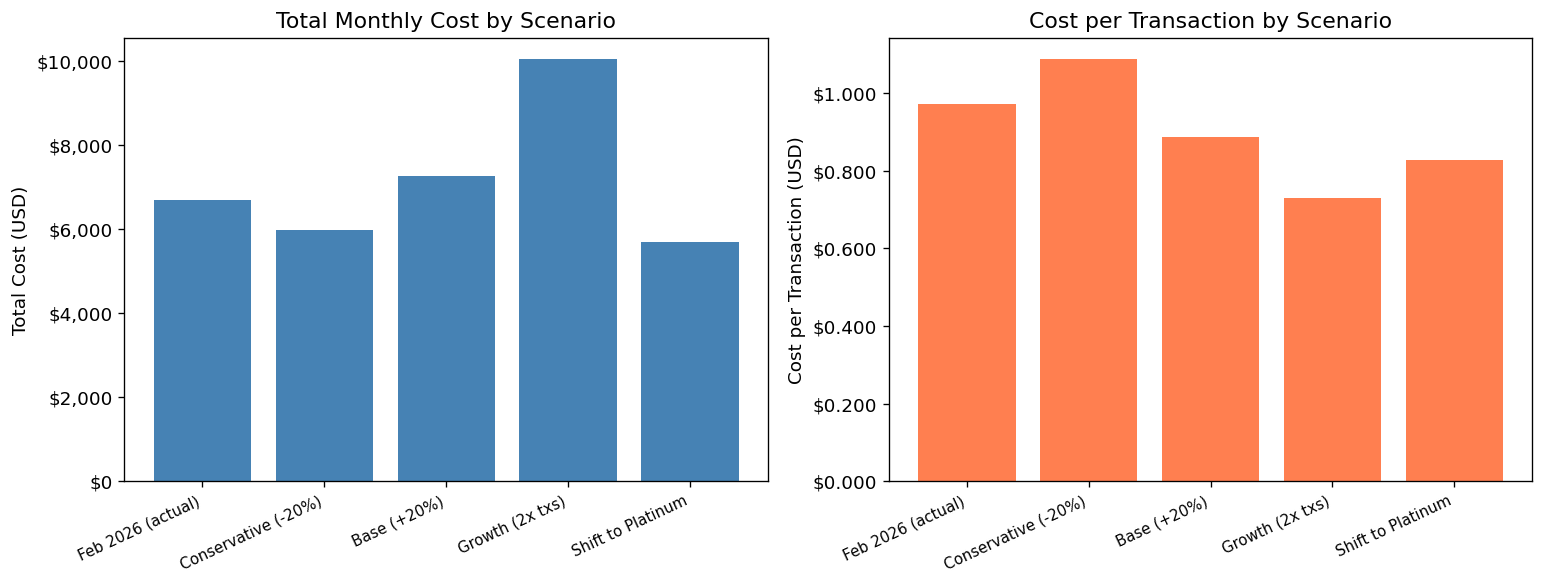

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

labels = df_scenarios['scenario']
x = range(len(labels))

ax1.bar(x, df_scenarios['total_cost_usd'], color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
ax1.set_ylabel('Total Cost (USD)')
ax1.set_title('Total Monthly Cost by Scenario')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y:,.0f}'))

ax2.bar(x, df_scenarios['cost_per_transaction_usd'], color='coral')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
ax2.set_ylabel('Cost per Transaction (USD)')
ax2.set_title('Cost per Transaction by Scenario')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y:.3f}'))

plt.tight_layout()
plt.show()

## 7. Projection — Deterministic (Single Month)

With only one invoice month, `project()` uses the rate model directly — exact cost for any input combination.

In [9]:
# Override only the inputs you expect to change next month
projected = sim.project(
    n_transactions=10_000,
    tx_volume_usd=300_000,
    n_active_cards=700,
    n_infinite_txs=1_200,
    n_share_tokens=900,
)

print(f"Projected total (next month estimate): ${projected:,.2f}")
print(f"vs February 2026 actual:               ${breakdown.total:,.2f}")
print(f"Delta:                                 ${projected - breakdown.total:+,.2f}")

Projected total (next month estimate): $8,318.81
vs February 2026 actual:               $6,693.57
Delta:                                 $+1,625.24


## 8. Projection — Linear Regression (Multi-Month)

Once you have multiple invoice months, fit a regression to capture variance beyond the rate model.
Replace the synthetic months below with real actuals as you receive each invoice.

In [10]:
from nbs_bi.cards.invoice_parser import CardInvoiceInputs
from dataclasses import asdict

feb = CardInvoiceInputs.from_february_2026()

# Replace these with real historical actuals as you accumulate invoice months
historical_months = [
    (feb, 6_693.58),   # Feb 2026 — actual
    (CardInvoiceInputs(**{**asdict(feb),
        'n_transactions': 5_200, 'n_active_cards': 510,
        'n_infinite_txs': 720, 'n_share_tokens': 630,
        'n_cross_border': 18_000}), 5_480.0),    # Jan 2026 — synthetic
    (CardInvoiceInputs(**{**asdict(feb),
        'n_transactions': 7_400, 'n_active_cards': 540,
        'n_infinite_txs': 950, 'n_share_tokens': 810,
        'n_cross_border': 26_500}), 7_100.0),    # Dec 2025 — synthetic
]

inputs_list  = [m[0] for m in historical_months]
actuals_list = [m[1] for m in historical_months]

coefficients = sim.fit_linear_model(inputs_list, actuals_list)

print("Linear model coefficients:")
for k, v in coefficients.items():
    print(f"  {k:<35} {v:>10.4f}")

Linear model coefficients:
  n_transactions                          0.4708
  n_active_cards                          0.1558
  tx_volume_usd                           0.0000
  n_infinite_txs                          0.0079
  n_platinum_txs                          0.0000
  n_share_tokens                          0.0627
  n_cross_border                          0.0666
  intercept                            1707.5944
  r_squared                               1.0000


In [11]:
# project() now uses the regression instead of the rate model
projected_reg = sim.project(
    n_transactions=10_000,
    tx_volume_usd=300_000,
    n_active_cards=700,
    n_infinite_txs=1_200,
    n_share_tokens=900,
)
print(f"Regression-based projection: ${projected_reg:,.2f}")

Regression-based projection: $8,189.57


## 9. Cost Curve — Volume Sensitivity

How does total cost and cost/tx evolve as transaction volume grows?
The base fee ($1,000/month) amortises — cost/tx drops as volume scales.

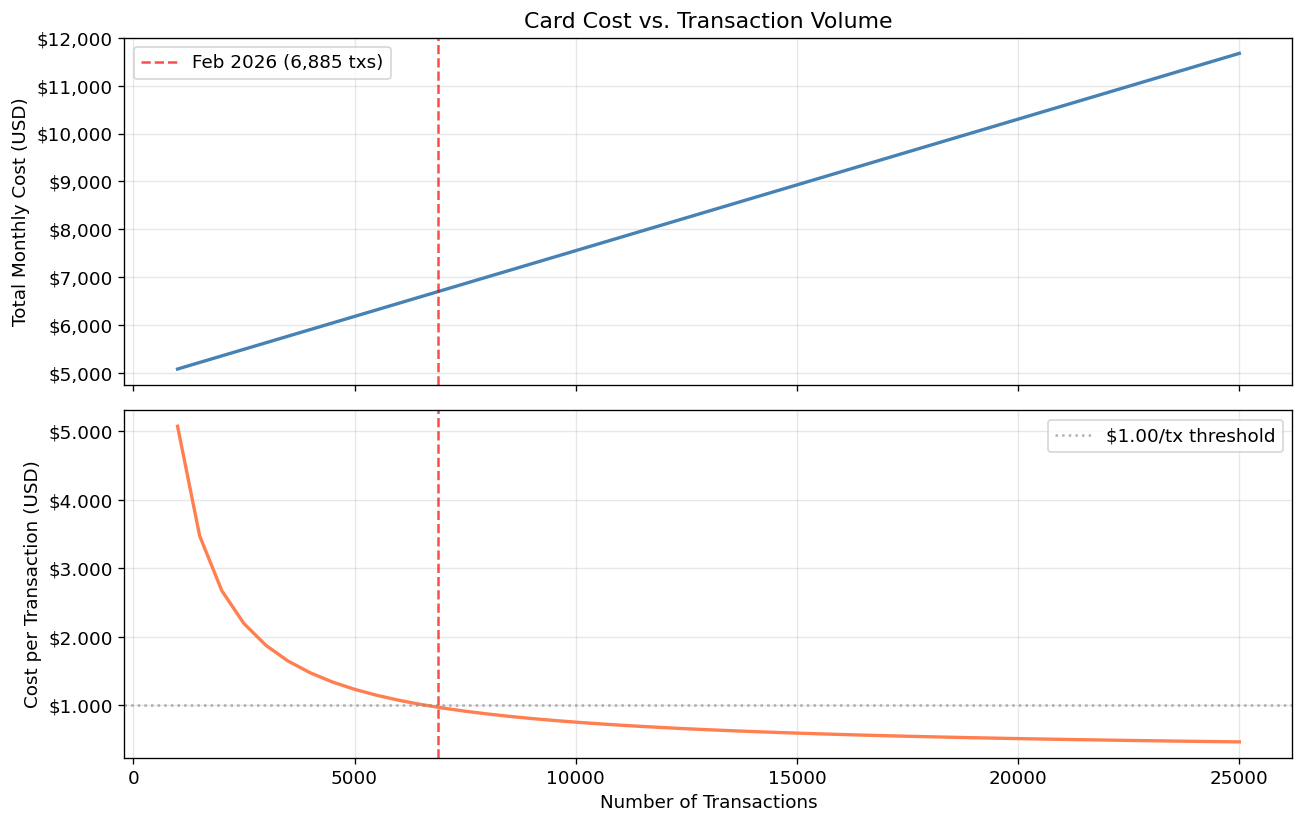

In [12]:
tx_range = list(range(1_000, 25_001, 500))
totals   = [sim.run(n_transactions=n).total_cost_usd for n in tx_range]
cpt_list = [sim.run(n_transactions=n).cost_per_transaction_usd for n in tx_range]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(tx_range, totals, color='steelblue', linewidth=2)
ax1.axvline(model.inputs.n_transactions, color='red', linestyle='--', alpha=0.7, label=f'Feb 2026 ({model.inputs.n_transactions:,} txs)')
ax1.set_ylabel('Total Monthly Cost (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y:,.0f}'))
ax1.legend()
ax1.set_title('Card Cost vs. Transaction Volume')
ax1.grid(alpha=0.3)

ax2.plot(tx_range, cpt_list, color='coral', linewidth=2)
ax2.axvline(model.inputs.n_transactions, color='red', linestyle='--', alpha=0.7)
ax2.axhline(1.0, color='grey', linestyle=':', alpha=0.6, label='$1.00/tx threshold')
ax2.set_xlabel('Number of Transactions')
ax2.set_ylabel('Cost per Transaction (USD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y:.3f}'))
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()